# Trečia užduotis: Vaizdų nuspalvinimas (Image Colorization)

**Versija:** 1.0 (2026-04-01)  
**Autorius:** Augustas Kniška  
**LSP numeris:** 2312054  
**Variantas:** Esami projekto duomenys iš `data/train/images`, `data/bee/images`, `data/castle/images`

## Tikslas
Sukurti modelį, kuris iš grayscale vaizdo (L kanalas) prognozuoja spalvinę informaciją (ab kanalai) ir atstato RGB vaizdą.

## Įgyvendinami reikalavimai
- Duomenų padalinimas į mokymo, validacijos ir testavimo aibes.
- Modelio mokymas.
- Metrikos testavimo aibei: PSNR, SSIM, MSE, MAE.
- Kelių testinių pavyzdžių vizualizacija: grayscale įvestis, modelio rezultatas, originalus vaizdas.
- Papildoma funkcija P2: REST API ir interaktyvi UI demonstracijai.

In [1]:
import os
import io
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from skimage import color
from skimage.metrics import peak_signal_noise_ratio, structural_similarity, mean_squared_error


# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Naudojamas įrenginys: {device}')

Naudojamas įrenginys: cpu


In [2]:
@dataclass
class Config:
    data_dirs: List[Path]
    image_size: int = 256
    train_ratio: float = 0.7
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    batch_size: int = 8
    num_epochs: int = 20
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    num_workers: int = 0
    model_save_path: Path = Path('models/colorization_unet_best.pth')


cfg = Config(
    data_dirs=[
        Path('data/train/images'),
        Path('data/bee/images'),
        Path('data/castle/images'),
    ]
)

assert abs(cfg.train_ratio + cfg.val_ratio + cfg.test_ratio - 1.0) < 1e-9, 'Split proporcijos turi sudaryti 1.0'
cfg.model_save_path.parent.mkdir(parents=True, exist_ok=True)


def gather_image_paths(directories: List[Path]) -> List[Path]:
    image_paths: List[Path] = []
    valid_ext = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    for directory in directories:
        if not directory.exists():
            print(f'Perspėjimas: katalogas nerastas: {directory}')
            continue
        for path in directory.rglob('*'):
            if path.suffix.lower() in valid_ext:
                image_paths.append(path)
    return sorted(image_paths)


all_image_paths = gather_image_paths(cfg.data_dirs)
print(f'Rasta vaizdų: {len(all_image_paths)}')
if len(all_image_paths) == 0:
    raise RuntimeError('Nerasta vaizdų nurodytuose kataloguose.')

Rasta vaizdų: 2246


In [3]:
def split_paths(paths: List[Path], train_ratio: float, val_ratio: float, seed: int = 42) -> Tuple[List[Path], List[Path], List[Path]]:
    rng = random.Random(seed)
    shuffled = paths.copy()
    rng.shuffle(shuffled)

    n_total = len(shuffled)
    n_train = int(n_total * train_ratio)
    n_val = int(n_total * val_ratio)

    train_paths = shuffled[:n_train]
    val_paths = shuffled[n_train:n_train + n_val]
    test_paths = shuffled[n_train + n_val:]
    return train_paths, val_paths, test_paths


train_paths, val_paths, test_paths = split_paths(all_image_paths, cfg.train_ratio, cfg.val_ratio, seed=SEED)
print(f'Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}')

Train: 1572 | Val: 336 | Test: 338


In [4]:
class ColorizationDataset(Dataset):
    def __init__(self, image_paths: List[Path], image_size: int = 256):
        self.image_paths = image_paths
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        rgb = np.array(image).astype(np.float32) / 255.0

        # LAB erdvėje L yra grayscale intensyvumas, o ab yra spalvų komponentės.
        lab = color.rgb2lab(rgb)
        l_channel = lab[:, :, 0:1] / 50.0 - 1.0
        ab_channels = lab[:, :, 1:] / 128.0

        l_tensor = torch.from_numpy(l_channel.transpose(2, 0, 1)).float()
        ab_tensor = torch.from_numpy(ab_channels.transpose(2, 0, 1)).float()

        return l_tensor, ab_tensor, str(image_path)


train_dataset = ColorizationDataset(train_paths, image_size=cfg.image_size)
val_dataset = ColorizationDataset(val_paths, image_size=cfg.image_size)
test_dataset = ColorizationDataset(test_paths, image_size=cfg.image_size)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

print(f'DataLoaderiai paruošti. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

DataLoaderiai paruošti. Train batches: 197, Val batches: 42, Test batches: 43


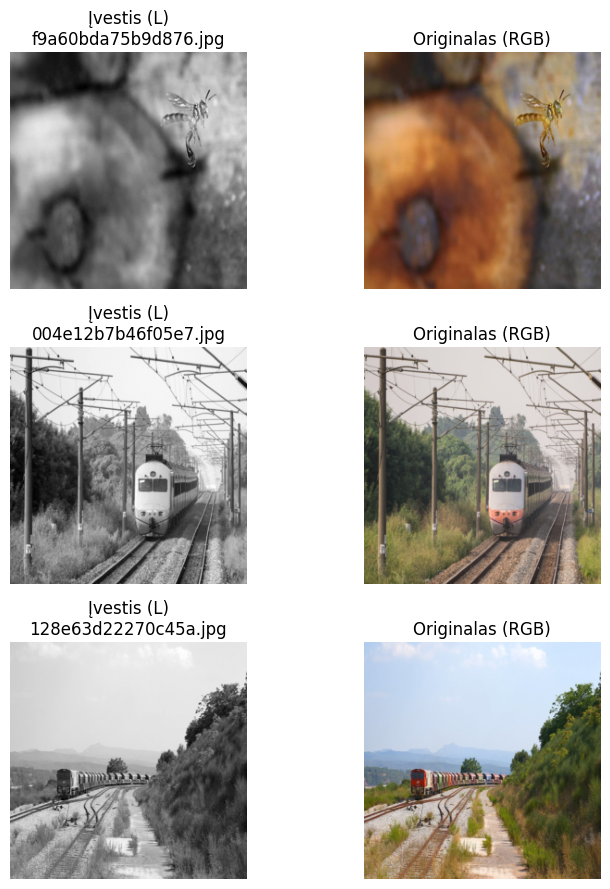

In [5]:
def denormalize_lab_to_rgb(l_tensor: torch.Tensor, ab_tensor: torch.Tensor) -> np.ndarray:
    l_np = l_tensor.detach().cpu().numpy()
    ab_np = ab_tensor.detach().cpu().numpy()

    if l_np.ndim == 3:
        l_np = l_np[None, ...]
    if ab_np.ndim == 3:
        ab_np = ab_np[None, ...]

    rgb_images = []
    for i in range(l_np.shape[0]):
        l_channel = (l_np[i].transpose(1, 2, 0) + 1.0) * 50.0
        ab_channels = ab_np[i].transpose(1, 2, 0) * 128.0
        lab_image = np.concatenate([l_channel, ab_channels], axis=-1)
        rgb_image = np.clip(color.lab2rgb(lab_image), 0.0, 1.0)
        rgb_images.append(rgb_image)
    return np.stack(rgb_images, axis=0)


def show_dataset_samples(dataset: ColorizationDataset, n_samples: int = 3):
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, 3 * n_samples))
    if n_samples == 1:
        axes = np.array([axes])

    for row in range(n_samples):
        l_tensor, ab_tensor, path = dataset[row]
        rgb = denormalize_lab_to_rgb(l_tensor, ab_tensor)[0]
        gray = ((l_tensor.squeeze(0).numpy() + 1.0) / 2.0)

        axes[row, 0].imshow(gray, cmap='gray')
        axes[row, 0].set_title(f'Įvestis (L)\n{Path(path).name}')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(rgb)
        axes[row, 1].set_title('Originalas (RGB)')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


show_dataset_samples(train_dataset, n_samples=min(3, len(train_dataset)))

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNetColorizer(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.out_conv = nn.Conv2d(64, 2, kernel_size=1)
        self.out_tanh = nn.Tanh()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_tanh(self.out_conv(d1))
        return out


model = UNetColorizer().to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Bendras parametrų skaičius: {total_params:,}')
print(f'Mokomų parametrų skaičius: {trainable_params:,}')

Bendras parametrų skaičius: 7,701,890
Mokomų parametrų skaičius: 7,701,890


In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)


history = {
    'train_loss': [],
    'val_loss': [],
}

best_val_loss = float('inf')

for epoch in range(cfg.num_epochs):
    model.train()
    train_losses = []

    for l_batch, ab_batch, _ in train_loader:
        l_batch = l_batch.to(device)
        ab_batch = ab_batch.to(device)

        optimizer.zero_grad()
        pred_ab = model(l_batch)
        loss = criterion(pred_ab, ab_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for l_batch, ab_batch, _ in val_loader:
            l_batch = l_batch.to(device)
            ab_batch = ab_batch.to(device)
            pred_ab = model(l_batch)
            loss = criterion(pred_ab, ab_batch)
            val_losses.append(loss.item())

    epoch_train_loss = float(np.mean(train_losses)) if train_losses else np.nan
    epoch_val_loss = float(np.mean(val_losses)) if val_losses else np.nan

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), cfg.model_save_path)

    print(
        f'Epoch {epoch + 1:02d}/{cfg.num_epochs} | '
        f'train_loss: {epoch_train_loss:.5f} | val_loss: {epoch_val_loss:.5f}'
    )

print(f'Geriausias modelis išsaugotas: {cfg.model_save_path}')

Epoch 01/20 | train_loss: 0.02233 | val_loss: 0.01702


In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE loss (ab kanalams)')
plt.title('Mokymo eiga')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.load_state_dict(torch.load(cfg.model_save_path, map_location=device))
model.eval()


def evaluate_model(model: nn.Module, data_loader: DataLoader) -> Dict[str, float]:
    psnr_values = []
    ssim_values = []
    mse_values = []
    mae_values = []

    with torch.no_grad():
        for l_batch, ab_batch, _ in data_loader:
            l_batch = l_batch.to(device)
            ab_batch = ab_batch.to(device)

            pred_ab = model(l_batch)

            pred_rgb = denormalize_lab_to_rgb(l_batch.cpu(), pred_ab.cpu())
            true_rgb = denormalize_lab_to_rgb(l_batch.cpu(), ab_batch.cpu())

            for pred_img, true_img in zip(pred_rgb, true_rgb):
                mse_val = mean_squared_error(true_img, pred_img)
                mae_val = float(np.mean(np.abs(true_img - pred_img)))
                psnr_val = peak_signal_noise_ratio(true_img, pred_img, data_range=1.0)
                ssim_val = structural_similarity(true_img, pred_img, data_range=1.0, channel_axis=-1)

                mse_values.append(float(mse_val))
                mae_values.append(mae_val)
                psnr_values.append(float(psnr_val))
                ssim_values.append(float(ssim_val))

    return {
        'PSNR': float(np.mean(psnr_values)) if psnr_values else np.nan,
        'SSIM': float(np.mean(ssim_values)) if ssim_values else np.nan,
        'MSE': float(np.mean(mse_values)) if mse_values else np.nan,
        'MAE': float(np.mean(mae_values)) if mae_values else np.nan,
    }


test_metrics = evaluate_model(model, test_loader)
print('Testavimo metrikos:')
for metric_name, metric_value in test_metrics.items():
    print(f'{metric_name}: {metric_value:.6f}')

In [ ]:
def visualize_test_predictions(model: nn.Module, dataset: ColorizationDataset, n_samples: int = 5):
    model.eval()
    n_samples = min(n_samples, len(dataset))

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))
    if n_samples == 1:
        axes = np.array([axes])

    with torch.no_grad():
        for i in range(n_samples):
            l_tensor, ab_tensor, path = dataset[i]
            l_input = l_tensor.unsqueeze(0).to(device)

            pred_ab = model(l_input).cpu().squeeze(0)

            pred_rgb = denormalize_lab_to_rgb(l_tensor, pred_ab)[0]
            true_rgb = denormalize_lab_to_rgb(l_tensor, ab_tensor)[0]
            gray = ((l_tensor.squeeze(0).numpy() + 1.0) / 2.0)

            axes[i, 0].imshow(gray, cmap='gray')
            axes[i, 0].set_title(f'Įvestis (grayscale)\n{Path(path).name}')
            axes[i, 0].axis('off')

            axes[i, 1].imshow(pred_rgb)
            axes[i, 1].set_title('Modelio rezultatas')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(true_rgb)
            axes[i, 2].set_title('Originalus RGB')
            axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()


visualize_test_predictions(model, test_dataset, n_samples=5)

In [ ]:
def colorize_pil_image(grayscale_image: Image.Image, model: nn.Module, image_size: int = 256) -> Image.Image:
    model.eval()

    gray = grayscale_image.convert('L').resize((image_size, image_size), Image.BILINEAR)
    gray_np = np.array(gray).astype(np.float32) / 255.0

    l_channel = gray_np[:, :, None] * 2.0 - 1.0
    l_tensor = torch.from_numpy(l_channel.transpose(2, 0, 1)).unsqueeze(0).float().to(device)

    with torch.no_grad():
        pred_ab = model(l_tensor).cpu().squeeze(0)

    pred_rgb = denormalize_lab_to_rgb(l_tensor.cpu().squeeze(0), pred_ab)[0]
    pred_rgb_uint8 = (pred_rgb * 255.0).astype(np.uint8)
    return Image.fromarray(pred_rgb_uint8)


# Greitas inferencijos testas su pirmu testiniu pavyzdžiu
sample_l, _, sample_path = test_dataset[0]
sample_gray = Image.fromarray((((sample_l.squeeze(0).numpy() + 1.0) / 2.0) * 255.0).astype(np.uint8), mode='L')
sample_colorized = colorize_pil_image(sample_gray, model, image_size=cfg.image_size)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_gray, cmap='gray')
plt.title('Įvestis')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_colorized)
plt.title('Nuspalvintas rezultatas')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f'Inferencijos testas atliktas su: {Path(sample_path).name}')

## P2: REST API ir interaktyvi UI

Žemiau pateikti minimalūs pavyzdžiai, kaip tą patį modelį naudoti:
- per REST API (FastAPI),
- per interaktyvią sąsają (Gradio).

Pastaba: šias celes galima paleisti po modelio apmokymo arba po modelio svorių įkėlimo iš `models/colorization_unet_best.pth`.

In [ ]:
# Jei trūksta bibliotekų, atkomentuokite ir paleiskite:
# !pip install fastapi uvicorn python-multipart gradio

from fastapi import FastAPI, UploadFile, File
from fastapi.responses import StreamingResponse
import uvicorn
import gradio as gr

api_app = FastAPI(title='Image Colorization API')


@api_app.post('/colorize')
async def colorize_endpoint(file: UploadFile = File(...)):
    image_bytes = await file.read()
    input_image = Image.open(io.BytesIO(image_bytes)).convert('L')
    output_image = colorize_pil_image(input_image, model, image_size=cfg.image_size)

    output_buffer = io.BytesIO()
    output_image.save(output_buffer, format='PNG')
    output_buffer.seek(0)

    return StreamingResponse(output_buffer, media_type='image/png')


# Paleidimas Jupyter aplinkoje (blokuoja šią celę, kol serveris veikia):
# uvicorn.run(api_app, host='0.0.0.0', port=8000)


def gradio_colorize(input_image: Image.Image) -> Image.Image:
    if input_image is None:
        return None
    return colorize_pil_image(input_image.convert('L'), model, image_size=cfg.image_size)


demo = gr.Interface(
    fn=gradio_colorize,
    inputs=gr.Image(type='pil', label='Įkelkite grayscale vaizdą'),
    outputs=gr.Image(type='pil', label='Nuspalvintas rezultatas'),
    title='Image Colorization Demo',
    description='Įkelkite juodai baltą nuotrauką ir peržiūrėkite modelio nuspalvintą rezultatą.'
)

# Paleidimui:
# demo.launch(share=False)

## Paleidimo seka atsiskaitymui

1. Paleisti importų ir konfigūracijos celes.
2. Paruošti duomenis ir DataLoaderius.
3. Apmokyti modelį arba įkelti jau išsaugotą modelį.
4. Paleisti testavimo metrikas (PSNR, SSIM, MSE, MAE).
5. Paleisti vizualizacijos celę su bent keliais testiniais pavyzdžiais.
6. Jei reikia P2 demonstracijos, paleisti REST API ir Gradio celes.

## Paaiškinimai, kuriuos reikia gebėti pateikti
- Duomenų paruošimas: RGB -> LAB, įvestis L, tikslas ab.
- Architektūra: U-Net encoder-decoder su skip jungtimis.
- Nuostolių funkcija: MSE tarp prognozuotų ir tikrų ab kanalų.
- Mokymas: epoch ciklas, validacija, geriausio checkpoint saugojimas.